# 🪩 Rave visualiser

Pick a **session + neuron + trial** and watch the animal rave its way to reward.
Firing rate pulses the comet, fires shockwave rings, scrolls the bottom panel and strobes the scene.
Outputs: inline video, MP4, GIF, and a long-exposure light-painting still.

Palettes: `ice_uv` (default), `neon_noir`, `plasma_fire`, `rainbow`.

In [28]:
%matplotlib inline
import importlib
import rave_visualiser as rv
importlib.reload(rv)
from IPython.display import HTML

### What's available?
Run this once to see mouse_recdays, sessions, #neurons and #trials (loads the ~3.5 GB pickle the first time).

In [29]:
rv.list_sessions()

Loading data_dic_lec.pkl (one-off, ~3.5 GB)…

ah08_20250613_20250615  (8 sessions)
   session 0: 151 neurons,  5 trials, task=[3 2 7 1]
   session 1: 151 neurons,  9 trials, task=[3 4 6 7]
   session 2: 151 neurons,  7 trials, task=[7 5 1 6]
   session 3: 151 neurons,  5 trials, task=[3 2 7 1]
   session 4: 151 neurons, 11 trials, task=[6 4 9 2]
   session 5: 151 neurons, 21 trials, task=[7 9 5 4]
   session 6: 151 neurons, 10 trials, task=[7 3 1 5]
   session 7: 151 neurons,  1 trials, task=[6 4 9 2]

ah08_20250616_20250617  (8 sessions)
   session 0: 164 neurons, 15 trials, task=[8 2 9 5]
   session 1: 164 neurons, 13 trials, task=[5 2 7 8]
   session 2: 164 neurons,  2 trials, task=[2 4 8 5]
   session 3: 164 neurons,  9 trials, task=[8 2 9 5]
   session 4: 164 neurons, 16 trials, task=[9 1 6 4]
   session 5: 164 neurons, 15 trials, task=[7 8 3 6]
   session 6: 164 neurons, 14 trials, task=[4 6 3 9]
   session 7: 164 neurons,  0 trials, task=[9 1 6 4]

ah08_20250618_20250619  (8 ses

### Choose your set

In [21]:
MOUSE_RECDAY = 'ah10_20250613_20250615'
SESSION      = 2
NEURON       = 51
TRIAL        = 2
PALETTE      = 'rainbow'   # ice_uv | neon_noir | plasma_fire | rainbow
FPS          = 30
SPEEDUP      = 2.0        # 3x faster than real time

session = rv.load_session(MOUSE_RECDAY, SESSION)
print(f"{session['label']}: {session['n_neurons']} neurons, {session['n_trials']} trials, "
      f"towers visited: {sorted(session['node_xy'])}")

ah10_20250613_20250615_s2: 139 neurons, 22 trials, towers visited: [1, 2, 3, 4, 5, 6, 7, 8, 9]


### Render + play inline

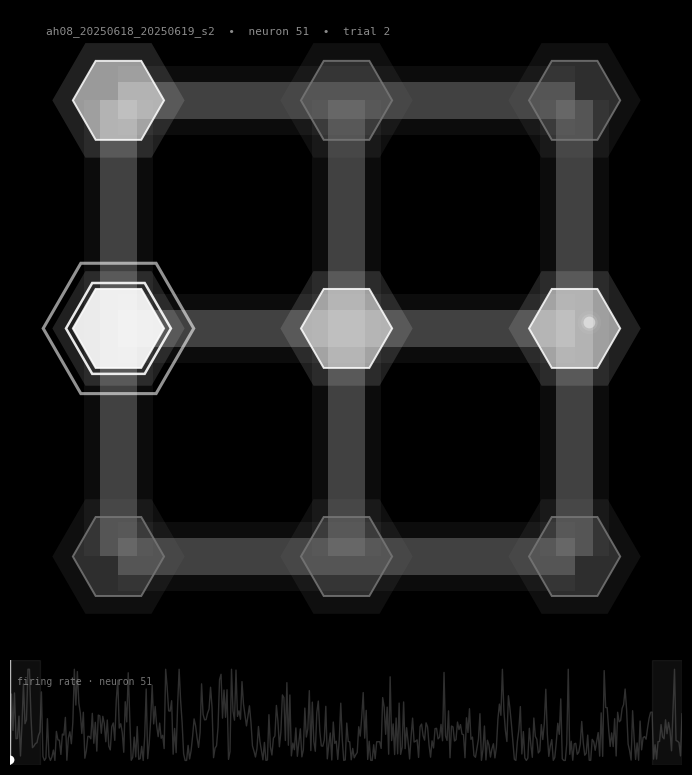

In [13]:
anim, fig = rv.render_rave(session, neuron=NEURON, trial=TRIAL,
                           palette=PALETTE, fps=FPS, speedup=SPEEDUP)
HTML(anim.to_html5_video())

### Save MP4 + GIF

In [14]:
base = f"{session['label']}_n{NEURON}_t{TRIAL}_{PALETTE}"
rv.save_outputs(anim, base, fps=FPS)

saved mp4 → /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_n51_t2_rainbow.mp4
saved gif → /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_n51_t2_rainbow.gif


{'mp4': '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_n51_t2_rainbow.mp4',
 'gif': '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_n51_t2_rainbow.gif'}

### Long-exposure light-painting still

In [ ]:
rv.render_long_exposure(session, neuron=NEURON, trial=TRIAL,
                        palette=PALETTE, speedup=SPEEDUP, fps=FPS);

### 🧠 Population version (PCA)

Same trial, but the right panel is a 2-D **PCA of the whole-session population activity**, with the single trial's window projected and coloured by task state (**A**→**B**→**C**→**D**). The maze comet now pulses with **overall population activity** instead of one neuron. PCA is fit once per session and cached.

In [36]:
MOUSE_RECDAY = 'ly06_20250613_20250615'
SESSION      = 1
TRIAL        = 4
PALETTE      = 'rainbow'   # ice_uv | neon_noir | plasma_fire | rainbow
FPS          = 30
SPEEDUP      = 2.0        # 3x faster than real time

session = rv.load_session(MOUSE_RECDAY, SESSION)
print(f"{session['label']}: {session['n_neurons']} neurons, {session['n_trials']} trials, "
      f"towers visited: {sorted(session['node_xy'])}")

ly06_20250613_20250615_s1: 68 neurons, 10 trials, towers visited: [1, 2, 3, 4, 5, 6, 7, 8, 9]


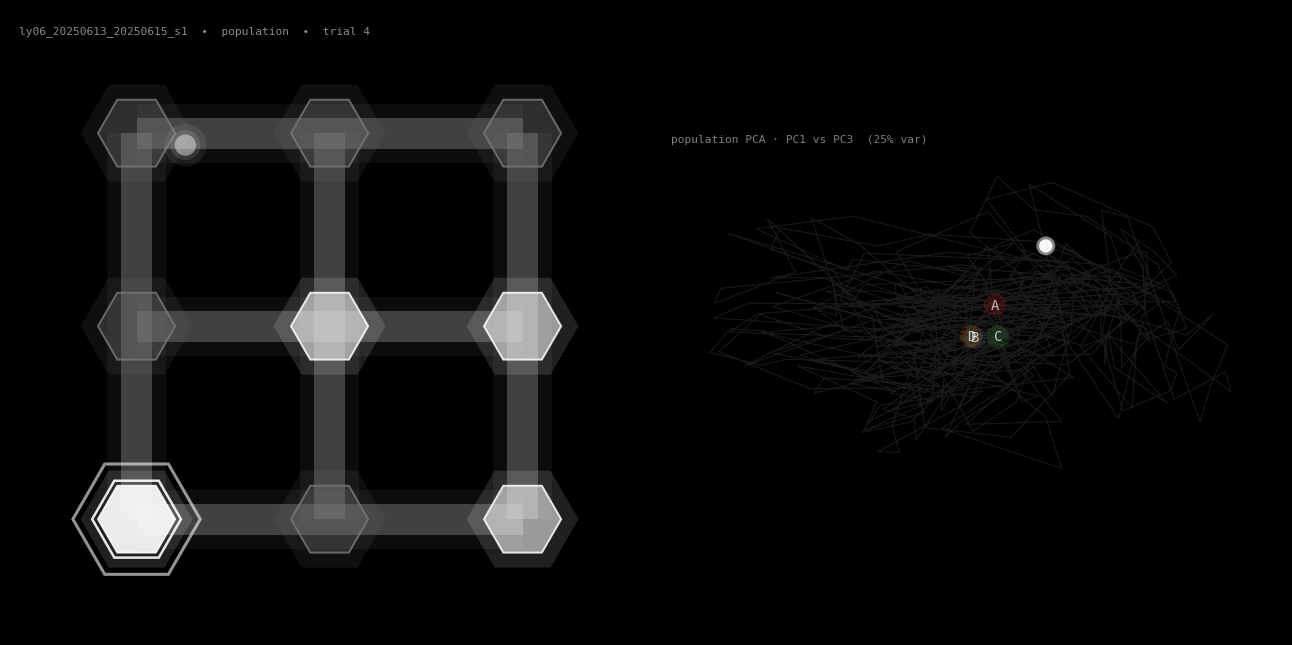

In [38]:
anim_pop, fig_pop = rv.render_rave_pop(session, trial=TRIAL,
                                       palette=PALETTE, fps=FPS, speedup=SPEEDUP,
                                       n_smooth=10, pc_x=0, pc_y=2)
HTML(anim_pop.to_html5_video())

In [ ]:
rv.save_outputs(anim_pop, f"{session['label']}_pop_t{TRIAL}_{PALETTE}", fps=FPS)

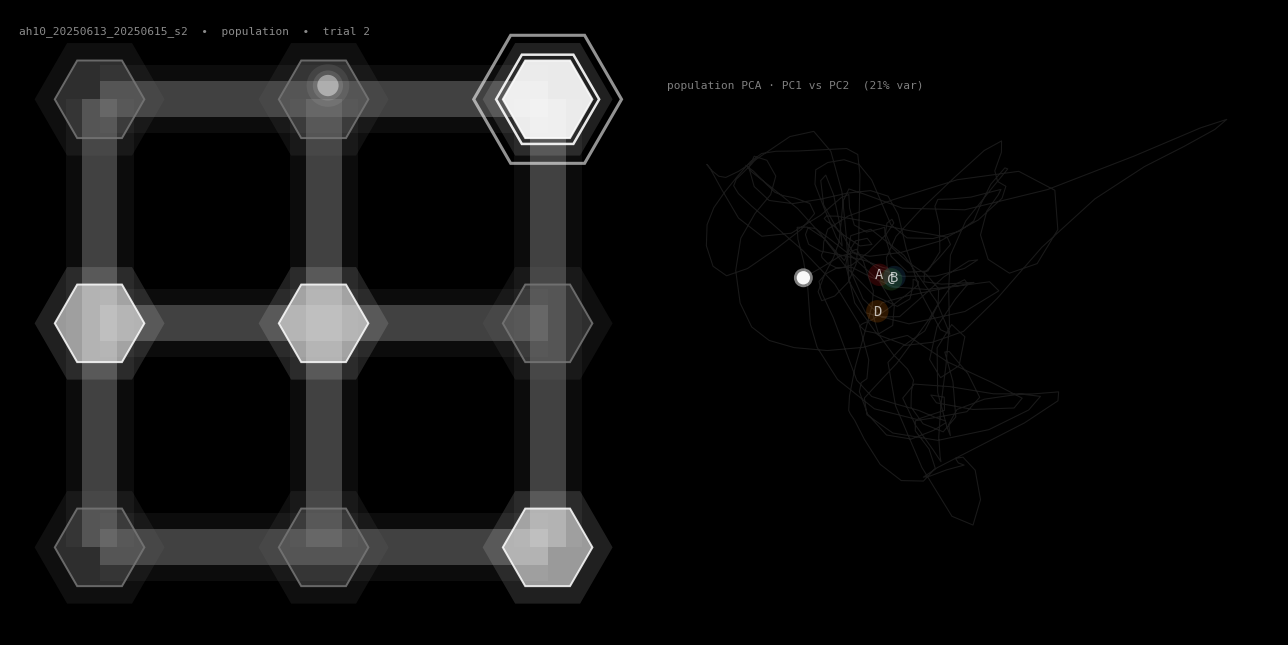

In [23]:
anim_pop, fig_pop = rv.render_rave_pop(session, trial=TRIAL,
                                       palette=PALETTE, fps=FPS, speedup=SPEEDUP,
                                       n_smooth=8, pc_x=0, pc_y=1)
HTML(anim_pop.to_html5_video())

In [19]:
rv.save_outputs(anim_pop, f"{session['label']}_pop_t{TRIAL}_{PALETTE}", fps=FPS)

saved mp4 → /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_pop_t2_rainbow.mp4
saved gif → /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_pop_t2_rainbow.gif


{'mp4': '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_pop_t2_rainbow.mp4',
 'gif': '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/code/rave_output/ah08_20250618_20250619_s2_pop_t2_rainbow.gif'}